# Feature Selection: SelectKBest + ANOVA (f_classif)

This notebook is a **first-pass feature selection baseline** for emotion classification.

What it does:
- loads one feature CSV
- separates metadata from model features
- trains a baseline model
- applies `SelectKBest(f_classif)`
- retrains and compares performance
- visualizes top ANOVA feature scores
- saves selected feature names and transformed datasets

**Default dataset key for this notebook:** `bert`


## 1) Imports and Notebook Settings

This cell sets up dependencies and plotting style.

In [4]:
from pathlib import Path
import json
import os
import sys
from contextlib import contextmanager

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from joblib import Parallel, delayed
from tqdm.auto import tqdm

plt.style.use('ggplot')
np.random.seed(42)

print('Imports loaded.')


Imports loaded.


## 2) Configuration

Pick which extracted feature table to run.

Recommended first run: `mfcc_raw` (fast and stable).

In [5]:
REPO_ROOT = Path.cwd().resolve().parents[2] if 'feature_selection' in str(Path.cwd()) else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from feature_selection.common import (
    DEFAULT_EXCLUDED_EMOTIONS,
    DEFAULT_REQUIRE_AGREEMENT,
    METADATA_CANDIDATES,
    filter_feature_frame,
    include_xxx_from_env,
    machine_name_from_env,
    parse_bool,
    resolve_anova_artifact_dir,
    resolve_cpu_parallel_config,
    resolve_feature_source,
    resolve_random_forest_jobs,
    use_variant_artifact_dirs_from_env,
    variant_name,
)

DATASET_KEY = 'bert'
TARGET_COL = 'emotion'
TEST_SIZE = 0.20
RANDOM_STATE = 42
K_FEATURES = 300       # can be int or 'all'; actual k is clipped to available features
USE_NROWS = None           # set e.g. 5000 for quick smoke runs on huge CSVs
REQUIRE_AGREEMENT = DEFAULT_REQUIRE_AGREEMENT
EXCLUDED_EMOTIONS = DEFAULT_EXCLUDED_EMOTIONS

MACHINE_NAME = machine_name_from_env()
INCLUDE_XXX = include_xxx_from_env(default=True)
VARIANT_NAME = variant_name(INCLUDE_XXX)
USE_VARIANT_ARTIFACT_DIRS = use_variant_artifact_dirs_from_env(default=True)
MODEL_PARALLEL_JOBS, MODEL_PARALLEL_MODE = resolve_cpu_parallel_config(MACHINE_NAME)
RANDOM_FOREST_JOBS = resolve_random_forest_jobs(MACHINE_NAME)

source_path = resolve_feature_source(REPO_ROOT, DATASET_KEY)
artifact_dir = resolve_anova_artifact_dir(
    REPO_ROOT,
    include_xxx=INCLUDE_XXX,
    use_variant_dirs=USE_VARIANT_ARTIFACT_DIRS,
)

print(f'Repository root: {REPO_ROOT}')
print(f'Selected source: {source_path}')
print('Source exists:', source_path.exists())
print(f'Machine: {MACHINE_NAME}')
print(f'Include xxx: {INCLUDE_XXX} ({VARIANT_NAME})')
print(f'Artifact dir: {artifact_dir}')
print(f'CPU model parallel jobs: {MODEL_PARALLEL_JOBS} | mode={MODEL_PARALLEL_MODE}')


REQUEST_REUSE_ARTIFACTS = parse_bool(os.getenv('SER_REUSE_ARTIFACTS'), default=(not INCLUDE_XXX))
FORCE_RECOMPUTE = parse_bool(os.getenv('SER_FORCE_RECOMPUTE'), default=False)
REUSE_EXISTING_ARTIFACTS = bool(REQUEST_REUSE_ARTIFACTS and not FORCE_RECOMPUTE)
selected_feature_path = artifact_dir / f'{DATASET_KEY}_selected_features.json'
rank_path = artifact_dir / f'{DATASET_KEY}_anova_ranking.csv'
train_sel_path = artifact_dir / f'{DATASET_KEY}_X_train_selected.csv'
test_sel_path = artifact_dir / f'{DATASET_KEY}_X_test_selected.csv'
meta_path = artifact_dir / f'{DATASET_KEY}_run_metadata.json'
print(f'Reuse existing artifacts requested: {REQUEST_REUSE_ARTIFACTS}')
print(f'Force recompute: {FORCE_RECOMPUTE}')


Repository root: /cluster/home/bekadb/Speech-Emotion-Recognition
Selected source: /cluster/home/bekadb/Speech-Emotion-Recognition/extracted_features/text/bert_embeddings.csv
Source exists: True
Machine: desktop
Include xxx: True (with_xxx)
Artifact dir: /cluster/home/bekadb/Speech-Emotion-Recognition/feature_selection/anova/select_k_best_anova/artifacts_with_xxx
CPU model parallel jobs: -1 | mode=auto


## 3) Load Data and Identify Feature Columns

This cell infers feature columns by excluding known metadata columns.

Rows loaded: 9887
Rows after variant filtering: 9887
Metadata columns (10): ['path', 'session', 'method', 'gender', 'emotion', 'n_annotators', 'agreement', 'utt_id', 'text', 'split']
Feature columns (768).
Sample feature columns: ['bert_emb_0000', 'bert_emb_0001', 'bert_emb_0002', 'bert_emb_0003', 'bert_emb_0004', 'bert_emb_0005', 'bert_emb_0006', 'bert_emb_0007', 'bert_emb_0008', 'bert_emb_0009']
Class distribution after filtering:
emotion
xxx    2507
fru    1849
neu    1708
ang    1103
sad    1084
exc    1041
hap     595
Name: count, dtype: int64


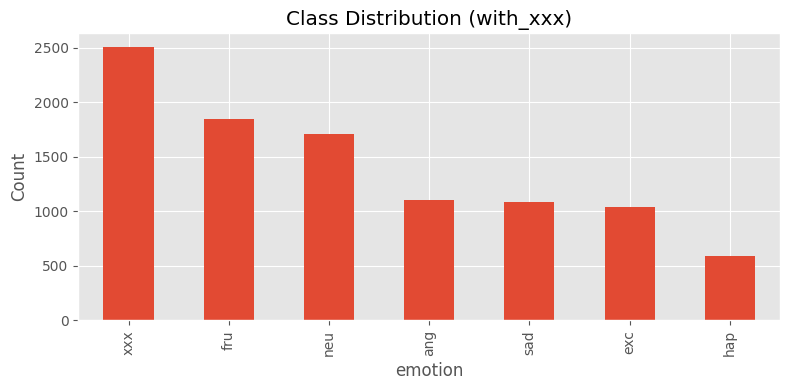

In [6]:

if REUSE_EXISTING_ARTIFACTS and meta_path.exists() and selected_feature_path.exists() and rank_path.exists() and train_sel_path.exists() and test_sel_path.exists():
    print('Artifact reuse enabled. Loading existing ANOVA artifacts for visualization.')
    with meta_path.open('r', encoding='utf-8') as f:
        run_meta = json.load(f)
    with selected_feature_path.open('r', encoding='utf-8') as f:
        selected_features = json.load(f)
    rank_df = pd.read_csv(rank_path)
    baseline_results = pd.DataFrame(run_meta.get('baseline_model_metrics', []))
    selected_results = pd.DataFrame(run_meta.get('selected_model_metrics', []))
    comparison_df = pd.DataFrame(run_meta.get('model_metric_deltas', []))
else:
    if REUSE_EXISTING_ARTIFACTS:
        print('Artifact reuse requested but required files were missing. Recomputing from source.')
    REUSE_EXISTING_ARTIFACTS = False

    if not source_path.exists():
        raise FileNotFoundError(f'Missing source CSV: {source_path}')

    raw_df = pd.read_csv(source_path, nrows=USE_NROWS)

    if TARGET_COL not in raw_df.columns:
        raise ValueError(f"Target column '{TARGET_COL}' not found. Available: {list(raw_df.columns[:20])}...")

    rows_loaded = len(raw_df)
    df = filter_feature_frame(
        raw_df,
        target_col=TARGET_COL,
        include_xxx=INCLUDE_XXX,
        require_agreement=REQUIRE_AGREEMENT,
        excluded_emotions=EXCLUDED_EMOTIONS,
    )

    meta_cols = [c for c in df.columns if c in METADATA_CANDIDATES]
    feature_cols = [c for c in df.columns if c not in METADATA_CANDIDATES]

    print(f'Rows loaded: {rows_loaded}')
    print(f'Rows after variant filtering: {len(df)}')
    print(f'Metadata columns ({len(meta_cols)}): {meta_cols}')
    print(f'Feature columns ({len(feature_cols)}).')
    print('Sample feature columns:', feature_cols[:10])

    class_counts = df[TARGET_COL].value_counts(dropna=False)
    print('Class distribution after filtering:')
    print(class_counts)

    fig, ax = plt.subplots(figsize=(8, 4))
    class_counts.plot(kind='bar', ax=ax)
    ax.set_title(f'Class Distribution ({VARIANT_NAME})')
    ax.set_xlabel(TARGET_COL)
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()


## 4) Basic Cleaning and Train/Test Split

Rows with missing labels or missing feature values are removed.

In [7]:
if REUSE_EXISTING_ARTIFACTS:
    print('Skipping train/test preparation because artifact reuse is active.')
else:
    model_df = df[[TARGET_COL] + feature_cols].copy()

    rows_before = len(model_df)
    model_df = model_df.dropna(subset=[TARGET_COL]).copy()
    usable_feature_cols = [c for c in feature_cols if model_df[c].notna().all()]
    dropped_feature_cols = [c for c in feature_cols if c not in usable_feature_cols]
    model_df = model_df[[TARGET_COL] + usable_feature_cols].dropna(axis=0, how='any').copy()
    rows_after = len(model_df)

    X = model_df[usable_feature_cols].astype(float)
    y_raw = model_df[TARGET_COL].astype(str)

    label_enc = LabelEncoder()
    y = label_enc.fit_transform(y_raw)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    print(f'Rows before cleaning: {rows_before}')
    print(f'Rows after cleaning:  {rows_after}')
    print(f'Dropped rows:         {rows_before - rows_after}')
    print(f'Feature columns used: {len(usable_feature_cols)}')
    print(f'Dropped feature columns with NaNs: {len(dropped_feature_cols)}')
    if dropped_feature_cols:
        print('Sample dropped feature columns:', dropped_feature_cols[:10])
    print(f'Train shape: {X_train.shape}')
    print(f'Test shape:  {X_test.shape}')
    print(f'Classes: {list(label_enc.classes_)}')


Rows before cleaning: 9887
Rows after cleaning:  9887
Dropped rows:         0
Feature columns used: 768
Dropped feature columns with NaNs: 0
Train shape: (7909, 768)
Test shape:  (1978, 768)
Classes: ['ang', 'exc', 'fru', 'hap', 'neu', 'sad', 'xxx']


## 5) Baseline Model (No Feature Selection)

A logistic regression baseline gives a reference before selection.

baseline: models:   0%|          | 0/3 [00:00<?, ?it/s]/cluster/home/bekadb/Speech-Emotion-Recognition/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Baseline metrics (all models):
   stage         model  accuracy  precision  recall     f1
baseline random_forest    0.4029     0.4297  0.4029 0.3977
baseline    linear_svc    0.3913     0.3979  0.3913 0.3843
baseline        logreg    0.3797     0.3897  0.3797 0.3713



[random_forest] classification report (baseline):
              precision    recall  f1-score   support

         ang       0.54      0.38      0.45       221
         exc       0.50      0.29      0.37       208
         fru       0.47      0.52      0.49       370
         hap       0.37      0.13      0.19       119
         neu       0.41      0.30      0.35       342
         sad       0.51      0.35      0.42       217
         xxx       0.31      0.53      0.39       501

    accuracy                           0.40      1978
   macro avg       0.45      0.36      0.38      1978
weighted avg       0.43      0.40      0.40      1978


[linear_svc] classification report (baseline):
              precision    recall  f1-score   support

         ang       0.41      0.56      0.47       221
         exc       0.35      0.44      0.39       208
         fru       0.45      0.47      0.46       370
         hap       0.22      0.36      0.27       119
         neu       0.45      0.38

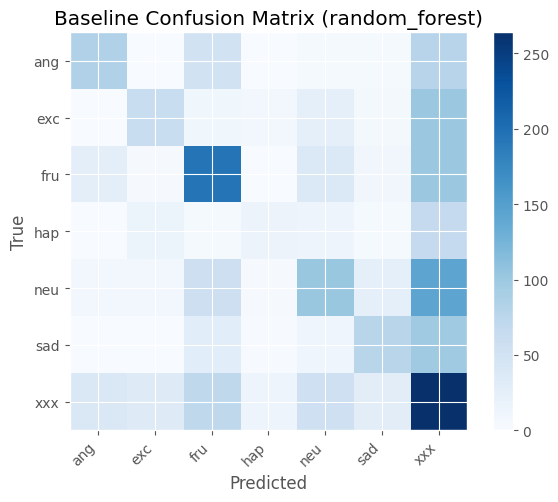

In [8]:
if REUSE_EXISTING_ARTIFACTS:
    print('Skipping baseline model training because artifact reuse is active.')
else:
    MODEL_SPECS = {
        'logreg': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=4000, class_weight='balanced', random_state=RANDOM_STATE)),
        ]),
        'linear_svc': Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, max_iter=8000)),
        ]),
        'random_forest': Pipeline([
            ('scaler', 'passthrough'),
            ('clf', RandomForestClassifier(
                n_estimators=500,
                class_weight='balanced_subsample',
                random_state=RANDOM_STATE,
                n_jobs=RANDOM_FOREST_JOBS,
            )),
        ]),
    }

    all_labels = np.arange(len(label_enc.classes_))


    @contextmanager
    def tqdm_joblib(tqdm_object):
        class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
            def __call__(self, *args, **kwargs):
                tqdm_object.update(n=self.batch_size)
                return super().__call__(*args, **kwargs)

        old_batch_callback = joblib.parallel.BatchCompletionCallBack
        joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback

        try:
            yield tqdm_object
        finally:
            joblib.parallel.BatchCompletionCallBack = old_batch_callback
            tqdm_object.close()


    def _resolve_model_jobs(requested_jobs: int, n_models: int) -> int:
        if requested_jobs == -1:
            return max(1, min(os.cpu_count() or 1, n_models))
        return max(1, min(int(requested_jobs), n_models))


    def _has_inner_parallelism(estimator) -> bool:
        params = estimator.get_params(deep=True)
        if 'clf__n_jobs' not in params:
            return False
        return params['clf__n_jobs'] not in (None, 1)


    def _fit_predict_single_model(
        model_name: str,
        estimator,
        X_train_eval,
        y_train_eval,
        X_test_eval,
        y_test_eval,
        stage_name: str,
        force_single_core_inner_model: bool,
    ):
        model = clone(estimator)

        if force_single_core_inner_model and 'clf__n_jobs' in model.get_params(deep=True):
            model.set_params(clf__n_jobs=1)

        model.fit(X_train_eval, y_train_eval)
        y_pred = model.predict(X_test_eval)

        row = {
            'stage': stage_name,
            'model': model_name,
            'accuracy': accuracy_score(y_test_eval, y_pred),
            'precision': precision_score(y_test_eval, y_pred, average='weighted', zero_division=0),
            'recall': recall_score(y_test_eval, y_pred, average='weighted', zero_division=0),
            'f1': f1_score(y_test_eval, y_pred, average='weighted'),
        }
        return model_name, row, y_pred


    def _evaluate_items_sequential(
        model_items,
        X_train_eval,
        y_train_eval,
        X_test_eval,
        y_test_eval,
        stage_name: str,
        desc: str,
        force_single_core_inner_model: bool,
    ):
        return [
            _fit_predict_single_model(
                model_name,
                estimator,
                X_train_eval,
                y_train_eval,
                X_test_eval,
                y_test_eval,
                stage_name,
                force_single_core_inner_model,
            )
            for model_name, estimator in tqdm(
                model_items,
                total=len(model_items),
                desc=desc,
                leave=False,
            )
        ]


    def _evaluate_items_parallel(
        model_items,
        requested_jobs: int,
        X_train_eval,
        y_train_eval,
        X_test_eval,
        y_test_eval,
        stage_name: str,
        desc: str,
        force_single_core_inner_model: bool,
    ):
        if not model_items:
            return []

        n_jobs = _resolve_model_jobs(requested_jobs, len(model_items))
        if n_jobs == 1:
            return _evaluate_items_sequential(
                model_items,
                X_train_eval,
                y_train_eval,
                X_test_eval,
                y_test_eval,
                stage_name,
                desc,
                force_single_core_inner_model,
            )

        with tqdm_joblib(tqdm(total=len(model_items), desc=desc, leave=False)):
            return Parallel(n_jobs=n_jobs, backend='loky')(
                delayed(_fit_predict_single_model)(
                    model_name,
                    estimator,
                    X_train_eval,
                    y_train_eval,
                    X_test_eval,
                    y_test_eval,
                    stage_name,
                    force_single_core_inner_model,
                )
                for model_name, estimator in model_items
            )


    def evaluate_models(X_train_eval, y_train_eval, X_test_eval, y_test_eval, stage_name: str):
        model_items = list(MODEL_SPECS.items())
        mode = str(MODEL_PARALLEL_MODE).strip().lower()
        if mode not in {'auto', 'outer', 'sequential'}:
            raise ValueError('MODEL_PARALLEL_MODE must be one of: auto, outer, sequential')

        requested_jobs = _resolve_model_jobs(MODEL_PARALLEL_JOBS, len(model_items))

        if mode == 'sequential' or requested_jobs == 1:
            evaluated = _evaluate_items_sequential(
                model_items,
                X_train_eval,
                y_train_eval,
                X_test_eval,
                y_test_eval,
                stage_name,
                desc=f'{stage_name}: models',
                force_single_core_inner_model=True,
            )
        else:
            if mode == 'outer':
                force_single_core_inner_model = True
            else:
                force_single_core_inner_model = any(_has_inner_parallelism(estimator) for _, estimator in model_items)

            evaluated = _evaluate_items_parallel(
                model_items,
                requested_jobs=requested_jobs,
                X_train_eval=X_train_eval,
                y_train_eval=y_train_eval,
                X_test_eval=X_test_eval,
                y_test_eval=y_test_eval,
                stage_name=stage_name,
                desc=f'{stage_name}: models',
                force_single_core_inner_model=force_single_core_inner_model,
            )

        rows = []
        preds = {}
        for model_name, row, y_pred in evaluated:
            rows.append(row)
            preds[model_name] = y_pred

        metrics_df = pd.DataFrame(rows).sort_values('f1', ascending=False, ignore_index=True)
        return metrics_df, preds


    def plot_confusion(y_true, y_pred, title: str):
        cm = confusion_matrix(y_true, y_pred, labels=all_labels)
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(cm, cmap='Blues')
        fig.colorbar(im, ax=ax)
        ax.set_title(title)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_xticks(range(len(label_enc.classes_)))
        ax.set_yticks(range(len(label_enc.classes_)))
        ax.set_xticklabels(label_enc.classes_, rotation=45, ha='right')
        ax.set_yticklabels(label_enc.classes_)
        plt.tight_layout()
        plt.show()


    baseline_results, baseline_preds = evaluate_models(X_train, y_train, X_test, y_test, stage_name='baseline')

    print('Baseline metrics (all models):')
    print(baseline_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

    for model_name in tqdm(
        baseline_results['model'],
        total=len(baseline_results),
        desc='baseline: classification reports',
        leave=False,
    ):
        print(f'\n[{model_name}] classification report (baseline):')
        print(classification_report(
            y_test,
            baseline_preds[model_name],
            labels=all_labels,
            target_names=label_enc.classes_,
            zero_division=0,
        ))

    best_baseline_model = baseline_results.loc[0, 'model']
    plot_confusion(y_test, baseline_preds[best_baseline_model], f'Baseline Confusion Matrix ({best_baseline_model})')

    base_acc = float(baseline_results.loc[0, 'accuracy'])
    base_f1 = float(baseline_results.loc[0, 'f1'])


## 6) SelectKBest (ANOVA F-test)

`f_classif` ranks each feature independently by class separability.

Original feature count: 768
Selected feature count: 300
First 15 selected features:
 - bert_emb_0001
 - bert_emb_0002
 - bert_emb_0003
 - bert_emb_0004
 - bert_emb_0006
 - bert_emb_0012
 - bert_emb_0014
 - bert_emb_0017
 - bert_emb_0018
 - bert_emb_0019
 - bert_emb_0020
 - bert_emb_0022
 - bert_emb_0028
 - bert_emb_0032
 - bert_emb_0037
Top 10 ANOVA-ranked features:
         feature  anova_f_score
0  bert_emb_0042      81.025754
1  bert_emb_0536      78.240050
2  bert_emb_0286      77.733103
3  bert_emb_0502      68.939226
4  bert_emb_0515      68.449582
5  bert_emb_0757      62.988467
6  bert_emb_0333      58.044770
7  bert_emb_0085      57.397300
8  bert_emb_0600      57.104096
9  bert_emb_0480      56.259924


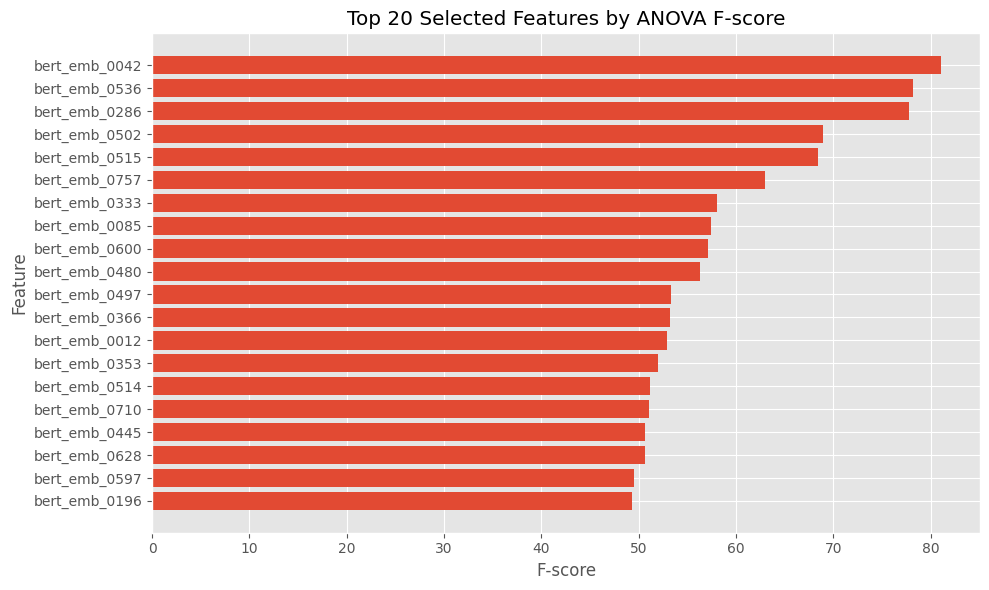

In [9]:
if REUSE_EXISTING_ARTIFACTS:
    print(f'Original feature count: {run_meta.get("original_features", "n/a")}')
    print(f'Selected feature count: {len(selected_features)}')
    print('Top 10 ANOVA-ranked features (from artifact):')
    print(rank_df.head(10))
    plot_n = min(20, len(rank_df))
    if plot_n > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        top_rank_df = rank_df.head(plot_n)
        ax.barh(top_rank_df['feature'][::-1], top_rank_df['anova_f_score'][::-1])
        ax.set_title(f'Top {plot_n} Selected Features by ANOVA F-score (artifact)')
        ax.set_xlabel('F-score')
        ax.set_ylabel('Feature')
        plt.tight_layout()
        plt.show()
else:
    if K_FEATURES == 'all':
        k = 'all'
    else:
        k = min(int(K_FEATURES), X_train.shape[1])

    selector = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X_train, y_train)

    mask = selector.get_support()
    selected_features = [col for col, keep in zip(usable_feature_cols, mask) if keep]
    selected_scores = selector.scores_[mask]

    print(f'Original feature count: {X_train.shape[1]}')
    print(f'Selected feature count: {len(selected_features)}')
    print('First 15 selected features:')
    for name in selected_features[:15]:
        print(' -', name)

    rank_df = pd.DataFrame({
        'feature': selected_features,
        'anova_f_score': selected_scores,
    }).sort_values('anova_f_score', ascending=False, ignore_index=True)

    print('Top 10 ANOVA-ranked features:')
    print(rank_df.head(10))

    plot_n = min(20, len(rank_df))
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(rank_df.head(plot_n)['feature'][::-1], rank_df.head(plot_n)['anova_f_score'][::-1])
    ax.set_title(f'Top {plot_n} Selected Features by ANOVA F-score')
    ax.set_xlabel('F-score')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()


## 7) Model After Selection

Train the same classifier, now only on selected features.

selected: models:   0%|          | 0/3 [00:00<?, ?it/s]/cluster/home/bekadb/Speech-Emotion-Recognition/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Post-selection metrics (all models):
   stage         model  accuracy  precision  recall     f1
selected random_forest    0.4166     0.4402  0.4166 0.4128
selected    linear_svc    0.3761     0.3882  0.3761 0.3666
selected        logreg    0.3589     0.3712  0.3589 0.3494



[random_forest] classification report (post-selection):
              precision    recall  f1-score   support

         ang       0.55      0.40      0.46       221
         exc       0.52      0.33      0.40       208
         fru       0.48      0.51      0.49       370
         hap       0.37      0.12      0.18       119
         neu       0.41      0.33      0.37       342
         sad       0.55      0.40      0.46       217
         xxx       0.32      0.53      0.40       501

    accuracy                           0.42      1978
   macro avg       0.46      0.37      0.40      1978
weighted avg       0.44      0.42      0.41      1978


[linear_svc] classification report (post-selection):
              precision    recall  f1-score   support

         ang       0.38      0.52      0.44       221
         exc       0.34      0.47      0.40       208
         fru       0.45      0.41      0.43       370
         hap       0.21      0.31      0.25       119
         neu       0.

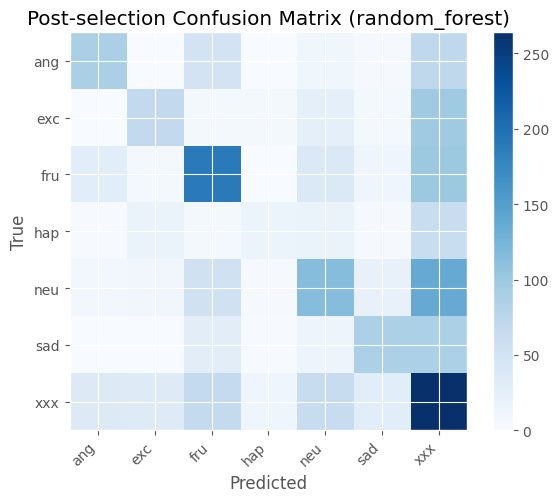


Metric delta by model (selected - baseline):
        model  accuracy_baseline  precision_baseline  recall_baseline  f1_baseline  accuracy_selected  precision_selected  recall_selected  f1_selected  accuracy_delta  precision_delta  recall_delta  f1_delta
random_forest             0.4029              0.4297           0.4029       0.3977             0.4166              0.4402           0.4166       0.4128          0.0137           0.0105        0.0137    0.0152
   linear_svc             0.3913              0.3979           0.3913       0.3843             0.3761              0.3882           0.3761       0.3666         -0.0152          -0.0097       -0.0152   -0.0178
       logreg             0.3797              0.3897           0.3797       0.3713             0.3589              0.3712           0.3589       0.3494         -0.0207          -0.0186       -0.0207   -0.0218


In [10]:
if REUSE_EXISTING_ARTIFACTS:
    print('Baseline metrics (loaded from metadata):')
    print(baseline_results.to_string(index=False, float_format=lambda x: f'{x:.4f}') if not baseline_results.empty else 'No baseline model metrics found.')
    print()
    print('Post-selection metrics (loaded from metadata):')
    print(selected_results.to_string(index=False, float_format=lambda x: f'{x:.4f}') if not selected_results.empty else 'No selected model metrics found.')
    if comparison_df.empty and not baseline_results.empty and not selected_results.empty:
        comparison_df = baseline_results[['model', 'accuracy', 'precision', 'recall', 'f1']].merge(
            selected_results[['model', 'accuracy', 'precision', 'recall', 'f1']], on='model', suffixes=('_baseline', '_selected')
        )
        comparison_df['accuracy_delta'] = comparison_df['accuracy_selected'] - comparison_df['accuracy_baseline']
        comparison_df['precision_delta'] = comparison_df['precision_selected'] - comparison_df['precision_baseline']
        comparison_df['recall_delta'] = comparison_df['recall_selected'] - comparison_df['recall_baseline']
        comparison_df['f1_delta'] = comparison_df['f1_selected'] - comparison_df['f1_baseline']
else:
    X_train_sel = selector.transform(X_train)
    X_test_sel = selector.transform(X_test)

    selected_results, selected_preds = evaluate_models(
        X_train_sel,
        y_train,
        X_test_sel,
        y_test,
        stage_name='selected',
    )

    print('Post-selection metrics (all models):')
    print(selected_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

    for model_name in tqdm(
        selected_results['model'],
        total=len(selected_results),
        desc='selected: classification reports',
        leave=False,
    ):
        print(f'\n[{model_name}] classification report (post-selection):')
        print(classification_report(
            y_test,
            selected_preds[model_name],
            labels=all_labels,
            target_names=label_enc.classes_,
            zero_division=0,
        ))

    best_selected_model = selected_results.loc[0, 'model']
    plot_confusion(y_test, selected_preds[best_selected_model], f'Post-selection Confusion Matrix ({best_selected_model})')

    comparison_df = baseline_results[['model', 'accuracy', 'precision', 'recall', 'f1']].merge(
        selected_results[['model', 'accuracy', 'precision', 'recall', 'f1']],
        on='model',
        suffixes=('_baseline', '_selected'),
    )
    comparison_df['accuracy_delta'] = comparison_df['accuracy_selected'] - comparison_df['accuracy_baseline']
    comparison_df['precision_delta'] = comparison_df['precision_selected'] - comparison_df['precision_baseline']
    comparison_df['recall_delta'] = comparison_df['recall_selected'] - comparison_df['recall_baseline']
    comparison_df['f1_delta'] = comparison_df['f1_selected'] - comparison_df['f1_baseline']
    comparison_df = comparison_df.sort_values('f1_selected', ascending=False, ignore_index=True)

    print('\nMetric delta by model (selected - baseline):')
    print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

    sel_acc = float(selected_results.loc[0, 'accuracy'])
    sel_f1 = float(selected_results.loc[0, 'f1'])


## 8) Save Artifacts

This exports selected feature names, scores, and transformed train/test matrices.

In [11]:
if REUSE_EXISTING_ARTIFACTS:
    print('Artifact reuse is active; skipping artifact rewrite.')
else:
    out_dir = artifact_dir
    out_dir.mkdir(parents=True, exist_ok=True)

    selected_feature_path = out_dir / f'{DATASET_KEY}_selected_features.json'
    rank_path = out_dir / f'{DATASET_KEY}_anova_ranking.csv'
    train_sel_path = out_dir / f'{DATASET_KEY}_X_train_selected.csv'
    test_sel_path = out_dir / f'{DATASET_KEY}_X_test_selected.csv'
    meta_path = out_dir / f'{DATASET_KEY}_run_metadata.json'

    with selected_feature_path.open('w', encoding='utf-8') as f:
        json.dump(selected_features, f, indent=2)

    rank_df.to_csv(rank_path, index=False)

    X_train_sel_df = pd.DataFrame(X_train_sel, columns=selected_features)
    X_test_sel_df = pd.DataFrame(X_test_sel, columns=selected_features)
    X_train_sel_df.to_csv(train_sel_path, index=False)
    X_test_sel_df.to_csv(test_sel_path, index=False)

    baseline_records = baseline_results.to_dict(orient='records')
    selected_records = selected_results.to_dict(orient='records')
    comparison_records = comparison_df.to_dict(orient='records')
    for collection in (baseline_records, selected_records, comparison_records):
        for row in collection:
            for key, value in list(row.items()):
                if isinstance(value, (np.floating, float)):
                    row[key] = float(value)

    run_meta = {
        'dataset_key': DATASET_KEY,
        'source_path': str(source_path),
        'artifact_dir': str(out_dir),
        'target_col': TARGET_COL,
        'machine_name': MACHINE_NAME,
        'include_xxx': bool(INCLUDE_XXX),
        'variant_name': VARIANT_NAME,
        'require_agreement': bool(REQUIRE_AGREEMENT),
        'excluded_emotions': list(EXCLUDED_EMOTIONS),
        'use_variant_artifact_dirs': bool(USE_VARIANT_ARTIFACT_DIRS),
        'rows_loaded': int(rows_loaded),
        'rows_after_filter': int(len(df)),
        'rows_used': int(len(model_df)),
        'original_features': int(X_train.shape[1]),
        'feature_columns_used': int(len(usable_feature_cols)),
        'dropped_feature_columns': int(len(dropped_feature_cols)),
        'selected_features': int(len(selected_features)),
        'classes': list(label_enc.classes_),
        'k_config': K_FEATURES,
        'k_effective': int(len(selected_features)),
        'random_state': RANDOM_STATE,
        'test_size': TEST_SIZE,
        'model_parallel_jobs': int(MODEL_PARALLEL_JOBS),
        'model_parallel_mode': MODEL_PARALLEL_MODE,
        'best_baseline_model': str(baseline_results.loc[0, 'model']),
        'best_selected_model': str(selected_results.loc[0, 'model']),
        'baseline_accuracy': float(base_acc),
        'baseline_precision': float(baseline_results.loc[0, 'precision']),
        'baseline_recall': float(baseline_results.loc[0, 'recall']),
        'baseline_f1': float(base_f1),
        'selected_accuracy': float(sel_acc),
        'selected_precision': float(selected_results.loc[0, 'precision']),
        'selected_recall': float(selected_results.loc[0, 'recall']),
        'selected_f1': float(sel_f1),
        'baseline_model_metrics': baseline_records,
        'selected_model_metrics': selected_records,
        'model_metric_deltas': comparison_records,
    }

    with meta_path.open('w', encoding='utf-8') as f:
        json.dump(run_meta, f, indent=2)

    print('Saved artifacts:')
    print('-', selected_feature_path)
    print('-', rank_path)
    print('-', train_sel_path)
    print('-', test_sel_path)
    print('-', meta_path)


Saved artifacts:
- /cluster/home/bekadb/Speech-Emotion-Recognition/feature_selection/anova/select_k_best_anova/artifacts_with_xxx/bert_selected_features.json
- /cluster/home/bekadb/Speech-Emotion-Recognition/feature_selection/anova/select_k_best_anova/artifacts_with_xxx/bert_anova_ranking.csv
- /cluster/home/bekadb/Speech-Emotion-Recognition/feature_selection/anova/select_k_best_anova/artifacts_with_xxx/bert_X_train_selected.csv
- /cluster/home/bekadb/Speech-Emotion-Recognition/feature_selection/anova/select_k_best_anova/artifacts_with_xxx/bert_X_test_selected.csv
- /cluster/home/bekadb/Speech-Emotion-Recognition/feature_selection/anova/select_k_best_anova/artifacts_with_xxx/bert_run_metadata.json


## 9) Notes for Next Methods

After this baseline, common next folders/methods:
- `wrapper/rfe_logreg/`
- `embedded/l1_logreg/`
- `embedded/tree_importance/`
- `dimensionality/pca/`

In [12]:
# Delta summary (selected - baseline)
if 'comparison_df' not in globals() or comparison_df is None or comparison_df.empty:
    raise RuntimeError('comparison_df not found. Run training/evaluation first, or load existing artifacts.')

delta_cols = [
    'model',
    'accuracy_baseline',
    'accuracy_selected',
    'accuracy_delta',
    'precision_baseline',
    'precision_selected',
    'precision_delta',
    'recall_baseline',
    'recall_selected',
    'recall_delta',
    'f1_baseline',
    'f1_selected',
    'f1_delta',
]

delta_table = comparison_df[delta_cols].copy().sort_values('f1_delta', ascending=False, ignore_index=True)

print('Delta table (selected - baseline):')
print(delta_table.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print('\nDelta accuracy only:')
print(
    delta_table[['model', 'accuracy_baseline', 'accuracy_selected', 'accuracy_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta precision only:')
print(
    delta_table[['model', 'precision_baseline', 'precision_selected', 'precision_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta recall only:')
print(
    delta_table[['model', 'recall_baseline', 'recall_selected', 'recall_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

print('\nDelta F1 only:')
print(
    delta_table[['model', 'f1_baseline', 'f1_selected', 'f1_delta']]
    .to_string(index=False, float_format=lambda x: f'{x:.4f}')
)

best_gain_row = delta_table.iloc[0]
print(
    f"\nBest F1 gain: {best_gain_row['model']} | "
    f"Delta F1={best_gain_row['f1_delta']:+.4f}, "
    f"Delta Accuracy={best_gain_row['accuracy_delta']:+.4f}"
)


Delta table (selected - baseline):
        model  accuracy_baseline  accuracy_selected  accuracy_delta  precision_baseline  precision_selected  precision_delta  recall_baseline  recall_selected  recall_delta  f1_baseline  f1_selected  f1_delta
random_forest             0.4029             0.4166          0.0137              0.4297              0.4402           0.0105           0.4029           0.4166        0.0137       0.3977       0.4128    0.0152
   linear_svc             0.3913             0.3761         -0.0152              0.3979              0.3882          -0.0097           0.3913           0.3761       -0.0152       0.3843       0.3666   -0.0178
       logreg             0.3797             0.3589         -0.0207              0.3897              0.3712          -0.0186           0.3797           0.3589       -0.0207       0.3713       0.3494   -0.0218

Delta accuracy only:
        model  accuracy_baseline  accuracy_selected  accuracy_delta
random_forest             0.4029       